In [1]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm


from CityScapes import PreprocessedCityscapesDataset
from file_management import get_version_folder, save_config, load_config
from model import init_weights


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
root = 'cache'
index_folder = get_version_folder(root)
config = load_config('hyperparameters.yaml')
config['learning']['model_path'] = os.path.join(index_folder, 'model.pth')

config_target_path = os.path.join(index_folder,'config.yaml')
save_config(config, config_target_path)



Config saved to cache/45/config.yaml


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# from model.reconstruction_decoder import ReconstructionDecoder
# from model.segmentation_decoder import SegmentationDecoder
from model.modules import Encoder,Decoder

class Model(nn.Module):
        def __init__(self,
                        in_channels=3, 
                        # encoder parameters
                        encoder_channels= [32, 64, 128, 256, 512, 1024,2048],
                        encoder_norm=nn.BatchNorm2d,
                        encoder_activation=nn.ReLU(inplace=True),
                        input_size = (512,512),
                        # reconstruction decoder parameters
                        number_of_components=4,
                        degrees_of_freedom=32,
                        vector_dim=256,
                        vectorizer_linear_layer_dim =[1024],
                        vectorizer_norm=nn.LayerNorm,
                        vectorizer_activation=nn.ReLU(inplace=True),
                        rec_dec_channels=[2048,1024,512,256,128,64,32,16],
                        rec_dec_first_conv_size= 4,
                        rec_dec_double_conv=True,
                        rec_dec_norm=nn.BatchNorm2d,
                        rec_dec_activation=nn.ReLU(inplace=True),
                        rec_dec_output_layer_activation=nn.Sigmoid(),
                        # segmentation decoder parameters
                        seg_dec_linear_in_neurons=1024,
                        seg_dec_linear_out_neurons=256,
                        seg_dec_linear_layer_dim=[],
                        seg_dec_linear_norm=nn.LayerNorm,
                        seg_dec_linear_activation=nn.ReLU(inplace=True),
                        seg_dec_channels=[2048,1024,512,256,128,64,32,16],
                        seg_dec_first_conv_size= 4,
                        seg_dec_double_conv=True,
                        seg_dec_norm=nn.BatchNorm2d,
                        seg_dec_activation=nn.ReLU(inplace=True),
                        seg_dec_output_layer_activation=nn.Softmax(dim=1)):

                super().__init__()
                self.in_channels = in_channels
                # encoder parameters
                self.encoder_channels = encoder_channels
                self.encoder_norm = encoder_norm
                self.encoder_activation = encoder_activation
                self.input_size = input_size
                # reconstruction decoder parameters
                self.number_of_components = number_of_components
                self.degrees_of_freedom = degrees_of_freedom
                self.vector_dim = vector_dim
                self.vectorizer_linear_layer_dim= vectorizer_linear_layer_dim.copy()
                self.vectorizer_norm = vectorizer_norm
                self.vectorizer_activation = vectorizer_activation
                self.rec_dec_channels = rec_dec_channels.copy()
                self.rec_dec_first_conv_size = rec_dec_first_conv_size
                self.rec_dec_double_conv = rec_dec_double_conv
                self.rec_dec_norm = rec_dec_norm
                self.rec_dec_activation = rec_dec_activation
                self.rec_dec_output_layer_activation = rec_dec_output_layer_activation
        

                # segmentation decoder parameters
                self.seg_dec_linear_in_neurons = seg_dec_linear_in_neurons  
                self.seg_dec_linear_out_neurons = seg_dec_linear_out_neurons
                self.seg_dec_linear_layer_dim = seg_dec_linear_layer_dim.copy()
                self.seg_dec_linear_norm = seg_dec_linear_norm
                self.seg_dec_linear_activation = seg_dec_linear_activation
                self.seg_dec_channels = seg_dec_channels.copy()
                self.seg_dec_first_conv_size = seg_dec_first_conv_size
                self.seg_dec_double_conv = seg_dec_double_conv
                self.seg_dec_norm = seg_dec_norm
                self.seg_dec_activation = seg_dec_activation
                self.seg_dec_output_layer_activation = seg_dec_output_layer_activation
                
                self.encoder = Encoder(in_channels=self.in_channels,
                                channels=self.encoder_channels,
                                norm=self.encoder_norm,
                                activation=self.encoder_activation,
                                input_size=self.input_size)
                with torch.no_grad():
                        dummy_x = torch.randn(1,self.in_channels,*self.input_size)
                        dummy_out = self.encoder(dummy_x)
                        encoder_output_shape = dummy_out.shape[1]

                self.decoder = Decoder( bottleneck_dim=encoder_output_shape,
                                        out_channels=self.in_channels,
                                        output_layer_activation=self.rec_dec_output_layer_activation,
                                        channels=self.rec_dec_channels,
                                        first_conv_size=self.rec_dec_first_conv_size,
                                        norm=self.rec_dec_norm,
                                        activation=self.rec_dec_activation)
        def forward(self, x):
            x = self.encoder(x)
            x= x.unsqueeze(-1).unsqueeze(-1)
            x = self.decoder(x)
            return x   


In [4]:
train_dataset = PreprocessedCityscapesDataset(get_labels=False)
train_dataloader = DataLoader(train_dataset, batch_size=config['learning']['batch_size'], shuffle=True)

model = Model(**config['model']).to(device)
# model.apply(init_weights)

optimizer = config['learning']['optimizer'](model.parameters(), lr=config['learning']['lr'])
reconstruction_loss_fn = config['learning']['loss_fn']
segmentation_loss_fn =config['learning']['segmentation_loss']

vector_similarity_loss_fn = config['learning']['vector_similarity_loss']

losses_list= []


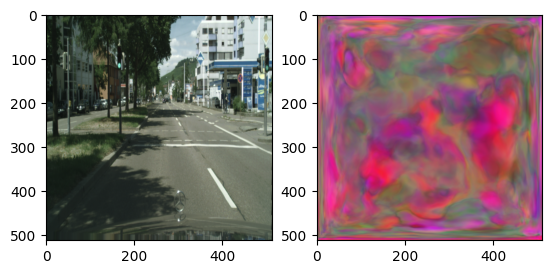

In [5]:

x= next(iter(train_dataloader))
# x = augmentations(x)
x= x.to(device)
rec = model(x)

show =0
fig,ax = plt.subplots(1,2)
ax[0].imshow(x.detach().cpu()[show].permute(1,2,0))
ax[1].imshow(rec.detach().cpu()[show].permute(1,2,0))


In [6]:
epochs = 1

for epoch in range(epochs):
    loop = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}')
    # loop = tqdm(range(len(train_dataloader)))
    for batch in loop:
        optimizer.zero_grad()
        batch = batch.to(device)
        # batch=  augmentations(batch)
        rec = model(batch)
       
        loss = reconstruction_loss_fn(rec, batch)

        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())
        losses_list.append(loss.item())
                                                                            
    torch.save(model.state_dict(), config['learning']['model_path'])

Epoch 1/1:  89%|████████▊ | 2216/2500 [10:50<01:23,  3.41it/s, loss=0.0096] 


KeyboardInterrupt: 

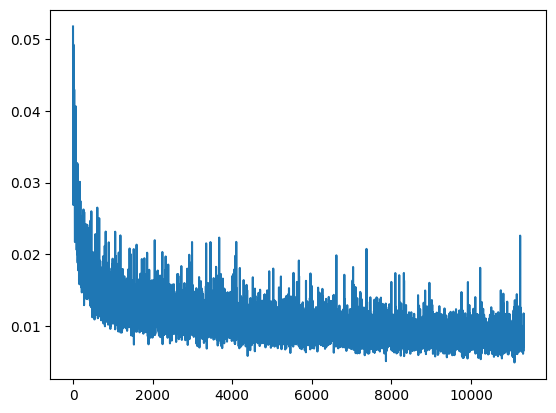

In [ ]:
plt.plot(losses_list)

In [ ]:

x= next(iter(train_dataloader))
# x = augmentations(x)
x= x.to(device)
rec = model(x)

show =5
fig,ax = plt.subplots(1,2)
ax[0].imshow(x.detach().cpu()[show].permute(1,2,0))
ax[1].imshow(rec.detach().cpu()[show].permute(1,2,0))
